# Loading and Creating a *Preliminary* Feature Vector

This notebook shows how to create a preliminary feature vector. 

If FISM2 data isn't avialable we use the EUVPy package and NEUVAC model to model
the required FISM2 wavebands using F10.7. 

If OMNI data isn't avaialbe we use the preliminary Dst data avialable from Kyoto. 

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import datetime
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs

In [ ]:
import mltdm.den_fx as den_fx
from mltdm.den_fx import fx_feat
from mltdm.den_fx import fx_den
den_fx.setup()

Setup Complete


In [ ]:
# creating a feature vector using preliminary data
# FISM2 data lags behind the current time by about
# two weeks

# lets load data with no FISM2 data, be sure to 
# use prelim=True

edate = datetime.datetime.now()
edate = edate.replace(minute=0,second=0,microsecond=0)
sdate = edate - relativedelta(days=7)


feat = fx_feat.load_feat(sdate=sdate,edate=edate, prelim=True)
feat

Download and loading daily save files from 2026-02-25-2026-03-10 09:00:00


  0%|          | 0/106 [00:00<?, ?it/s]

## Plotting using Preliminary Feature Data

Plotting stays the same except you pass the keyword ```prelim=True``` in order to 
get data from the NEUVAC model and Kyoto website.

In [ ]:
# load the model
rf_mod = fx_den(dropAE=True)


Loading fx_den_noAE_bz2.skops, this will take a few minutes.
Download and loading daily save files from 2026-02-25-2026-03-10 08:47:04.677968


  0%|          | 0/106 [00:21<?, ?it/s]


found attribute
2026-03-01 00:00:00 - 2026-03-10 08:00:00
Download and loading daily save files from 2026-02-25-2026-03-10 08:47:04.677968


  0%|          | 0/106 [00:21<?, ?it/s]


In [ ]:
# Derive Geographic and MLT predictions
denGeo = rf_mod.pred_den_geo(sdate=sdate, edate=edate,prelim=True)
denMLT = rf_mod.pred_den_mlt(sdate=sdate, edate=edate,prelim=True)

In [32]:
print(edate)
print(dmax)

2026-03-10 08:47:04.677968
2026-03-10 08:00:00


In [30]:
import pandas as pd
dmin = rf_mod.feat['DateTime'].min()
dmax = rf_mod.feat['DateTime'].max()

if pd.to_datetime(sdate) < dmin or pd.to_datetime(edate) > dmax:
    print('hi')

hi


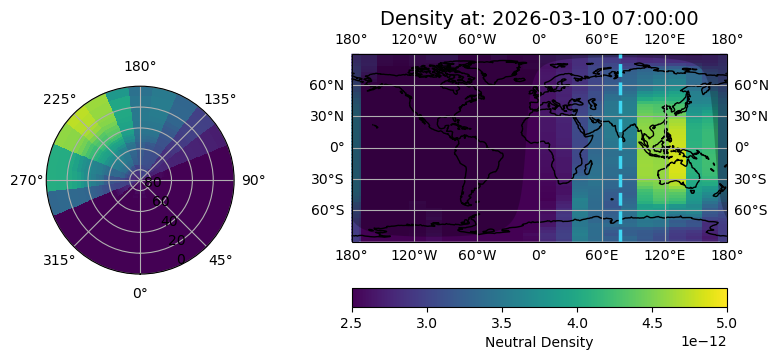

In [22]:
date = datetime.datetime.now()-relativedelta(hours=2)
date = date.replace(minute=0, second=0, microsecond=0)
vmin = 2.5E-12
vmax = 5E-12

fig = plt.figure(figsize=(10,4))

gs = GridSpec(1, 2, width_ratios=[1, 2])
ax1 = fig.add_subplot(gs[0], projection='polar')
ax2 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())

pol_im = rf_mod.plot_dpolar(denMLT, ax=ax1,date=date,vmin=vmin,vmax=vmax)
geo_im = rf_mod.plot_dgeo(denGeo, ax=ax2,date=date,vmin=vmin,vmax=vmax)

fig.delaxes(fig.axes[2])
fig.delaxes(fig.axes[2])

fig.colorbar(geo_im, ax=ax2, orientation='horizontal', label='Neutral Density')

fig.savefig('Overview.PDF')